In [1]:
m=0.5                                   
h1=1
x_0=-0.5
x_1=0.5

In [2]:
import numpy as np                                                      #  matrix coupling
import matplotlib.pyplot as plt
def coupling(matrix_1,matrix_2):                                 
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result                                                   
def multiple_coupling(matrix_collect_1):                                  #  multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2

In [3]:
def coupling_matrix_of_N_modified(N,n3,n4):             #coupling_matrix_of_N    N is period  n3 is (Sum of Plus second potential)
    location = np.linspace(x_0, x_1, 2*N+n3+n4)          #n4 is (Sum of Plus first potential)
    di=np.zeros((2*N+n3+n4),dtype=complex)
    for i in np.arange(2*N+n3+n4):
        if i<(2*N):
            di[i]=constant_1*(-1)**(i)
        if i>=(2*N) and i<(2*N+n3):
            di[i]=constant_1
        if i>=(2*N+n3):
            di[i]=constant_1*(-1)
    matrix_collect = np.zeros((2*N+n3+n4, 2, 2), dtype=complex)
    for i in np.arange(2*N+n3+n4):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(2*N+n3+n4))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
  #  print(matrix_collect)
    return matrix_6
def Transmission_coefficient_of_N_modified(N,n3,n4):
    return float(abs(coupling_matrix_of_N_modified(N,n3,n4)[1][0]**2))
def Reflection_coefficient_of_N_modified(N,n3,n4):
    return float(abs(coupling_matrix_of_N_modified(N,n3,n4)[0][0]**2))

In [73]:
#constant
y=1+0.1j
E=1
k=E**0.5
constant_1=2*m*y/(h1**2)
ss=Transmission_coefficient_of_N_modified(1,0,0)
dd=Reflection_coefficient_of_N_modified(1,0,0)
print(ss,dd,ss+dd)

0.5069711446796619 0.49036580734403606 0.9973369520236979


In [ ]:
m=0.5                                   
h1=1
x_0=-0.55
x_1=0.60
n=0
k_set=np.linspace(0,10,1000)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y1=i*1j
    constant_1=2*m*y1/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N_modified(0,1,0)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 10,11)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()
#print(y_all_set[0])

y_change [1.  1.2 1.4 1.6 1.8] value_all_set [[0.51224887 0.46147003 0.41064004 0.35962483 0.30907349]
 [0.45790412 0.58936457 0.74587626 0.92228954 1.1100031 ]
 [0.97015299 1.0508346  1.1565163  1.28191437 1.41907659]]


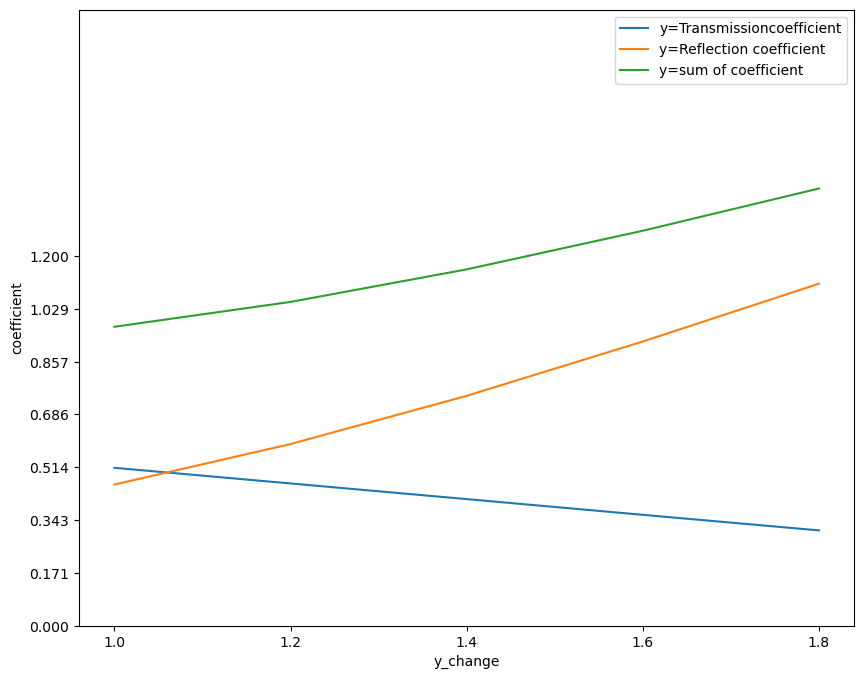

In [75]:
import matplotlib.pyplot as plt
k=1
y=1
n=100
y_change_1=np.arange(1,2,0.2)
y_change=y_change_1*1j
y_set_1=y_change+y
value_all_set=np.zeros((3,len(y_change)),dtype=float)
for h in np.arange(len(y_change)):
    y=y_set_1[h]
    constant_1=2*m*y/(h1**2) 
    value_all_set[0][h]=Transmission_coefficient_of_N_modified(n,0,0)
    value_all_set[1][h]=Reflection_coefficient_of_N_modified(n,0,0)
    value_all_set[2][h]=value_all_set[0][h]+value_all_set[1][h]
print('y_change',y_change_1,'value_all_set',value_all_set)
for i,l in zip(np.arange(3),['Transmissioncoefficient','Reflection coefficient','sum of coefficient']):
    plt.plot(y_change_1,value_all_set[i],label=f'y={l}')
new_ticks1 = y_change_1
new_ticks2 = np.linspace(0,1.2,8)
plt.xlabel('y_change')
plt.ylabel('coefficient')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0,2)
plt.rcParams['figure.figsize'] = (10, 8)
plt.legend()
plt.show()

In [12]:
new_ticks1 = np.linspace(0.0001,0.001,11)
print(new_ticks1)

[0.0001  0.00019 0.00028 0.00037 0.00046 0.00055 0.00064 0.00073 0.00082
 0.00091 0.001  ]
